# S07 — Group comparisons with FDR control (TAI+ vs TAI−)

Goal:
- Compare hormonal and metabolic markers between TAI+ and TAI− groups using TAI definition A.
- Control multiple testing using Benjamini–Hochberg FDR.

Outputs:
- Table5_group_differences_FDR.csv
- TableS_S07_missingness_by_group.csv
- F8_volcano_FDR.png
- F9_top_effects.png
- s7_group_comparisons_summary.json

## Imports

In [ ]:
import json
import logging
from pathlib import Path
from typing import Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu

## Config loading

In [ ]:
def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def resolve_config_path() -> Path:
    candidates = [
        Path("/content/reports/config_snapshot.json"),
        Path("/mnt/data/config_snapshot.json"),
        Path("/content/config.json"),
        Path("/mnt/data/config.json"),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "No config found. Expected config_snapshot.json or config.json in /content or /mnt/data."
    )

CONFIG_PATH = resolve_config_path()
CFG = load_json(CONFIG_PATH)

print("Loaded config:", str(CONFIG_PATH))

Loaded config: /content/config.json


## Directories and logging

In [ ]:
def ensure_dirs(cfg: dict) -> None:
    path_keys = [
        "output_dir",
        "intermediate_dir",
        "figures_dir",
        "tables_dir",
        "models_dir",
        "reports_dir",
        "qc_dir",
        "supplementary_dir",
    ]
    for key in path_keys:
        if key in cfg.get("paths", {}):
            Path(cfg["paths"][key]).mkdir(parents=True, exist_ok=True)

def setup_logging(cfg: dict) -> None:
    if not cfg.get("logging", {}).get("enabled", False):
        return

    root_logger = logging.getLogger()
    if root_logger.handlers:
        root_logger.setLevel(logging.INFO)
        return

    log_file = Path(cfg["logging"]["log_file"])
    log_file.parent.mkdir(parents=True, exist_ok=True)

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(message)s",
        handlers=[
            logging.FileHandler(log_file, encoding="utf-8"),
            logging.StreamHandler(),
        ],
    )
    logging.info("Logging initialized in S7.")
    logging.info("Config loaded from: %s", str(CONFIG_PATH))

ensure_dirs(CFG)
setup_logging(CFG)

tables_dir = Path(CFG["paths"]["tables_dir"])
figures_dir = Path(CFG["paths"]["figures_dir"])
reports_dir = Path(CFG["paths"]["reports_dir"])
intermediate_dir = Path(CFG["paths"]["intermediate_dir"])

RANDOM_SEED = int(CFG["project"]["random_seed"])
rng = np.random.default_rng(RANDOM_SEED)

## Data loading

In [ ]:
def resolve_analysis_data_paths(cfg: dict) -> List[Path]:
    return [
        Path(cfg["paths"]["intermediate_dir"]) / "pcos_analysis.parquet",
        Path(cfg["paths"]["intermediate_dir"]) / "pcos_analysis.csv",
        Path("/content/pcos_analysis.parquet"),
        Path("/content/pcos_analysis.csv"),
        Path("/mnt/data/pcos_analysis.parquet"),
        Path("/mnt/data/pcos_analysis.csv"),
    ]

def load_analysis_dataset(cfg: dict) -> Tuple[pd.DataFrame, str]:
    candidates = resolve_analysis_data_paths(cfg)

    parquet_candidates = [p for p in candidates if p.suffix == ".parquet" and p.exists()]
    csv_candidates = [p for p in candidates if p.suffix == ".csv" and p.exists()]

    for p in parquet_candidates:
        try:
            df = pd.read_parquet(p)
            return df, str(p)
        except Exception as e:
            logging.warning("Failed to read parquet %s: %r", str(p), e)

    for p in csv_candidates:
        try:
            df = pd.read_csv(p)
            return df, str(p)
        except Exception as e:
            logging.warning("Failed to read csv %s: %r", str(p), e)

    raise FileNotFoundError(
        "Could not locate pcos_analysis.parquet or pcos_analysis.csv in configured/intermediate locations."
    )

df, source_used = load_analysis_dataset(CFG)

print("Loaded:", source_used)
print("Shape:", df.shape)
df.head(3)

Loaded: /content/pcos_analysis.parquet
Shape: (1300, 77)


,id,age,anti_tpo,anti_tg,tsh,ft4,ft3,tg,hdl,tc,...,analysis_primary_minimal,analysis_non_hdl_minimal,analysis_ogtt120_minimal,exposure_tai_A_defined,endpoint_primary_defined,endpoint_non_hdl_defined,endpoint_ogtt120_defined,analysis_primary_eligible,analysis_non_hdl_eligible,analysis_ogtt120_eligible
0,7611,25.0,13.8,NaN,0.969,1.20,NaN,116.0,56.6,188.0,...,True,True,True,True,True,True,True,True,True,True
1,8133,25.0,12.6,NaN,2.050,1.18,NaN,144.0,41.9,196.0,...,True,True,True,True,True,True,True,True,True,True
2,11028,25.0,150.0,NaN,2.500,1.29,NaN,35.8,62.7,133.0,...,True,True,True,True,True,True,True,True,True,True


## Analysis setup and marker selection

In [ ]:
EXPOSURE = "tai_A"
if EXPOSURE not in df.columns:
    raise KeyError("Expected tai_A in df. Run S03 first.")

CANDIDATE_MARKERS = [
    # Thyroid / antibodies
    "anti_tpo", "tsh", "ft4", "anti_tg",

    # Lipids / glucose
    "tg", "hdl", "tc", "ldl", "non_hdl", "tg_hdl_ratio",
    "glu0", "glu120",

    # Androgens / hormones
    "tt", "ft", "shbg", "dheas", "andro", "amh", "lh", "fsh",
]

EXCLUDE_FROM_TESTS = {"anti_tpo"}  # definitional for TAI_A

MAX_MISSING_PCT = 80.0
FDR_TH = 0.10

markers_existing = [m for m in CANDIDATE_MARKERS if m in df.columns]
markers_testable = [m for m in markers_existing if m not in EXCLUDE_FROM_TESTS]

miss_pct_all = (df[markers_testable].isna().mean() * 100).sort_values(ascending=False)
markers_kept = [m for m in markers_testable if miss_pct_all[m] <= MAX_MISSING_PCT]
markers_dropped = [m for m in markers_testable if m not in markers_kept]

print("Markers existing:", len(markers_existing))
print("Markers testable:", len(markers_testable))
print("Kept (<=80% missing):", len(markers_kept))
print("Dropped (>80% missing):", markers_dropped)

Markers existing: 20
Markers testable: 19
Kept (<=80% missing): 16
Dropped (>80% missing): ['anti_tg', 'shbg', 'amh']


## Define analytic cohort

In [ ]:
df_g = df[df[EXPOSURE].notna()].copy()
df_g["TAI_group"] = np.where(
    pd.to_numeric(df_g[EXPOSURE], errors="coerce") == 1,
    "TAI+",
    "TAI−"
)

group_sizes = df_g["TAI_group"].value_counts(dropna=False)
print("Group sizes:\n", group_sizes)

n_tai_pos_total = int((df_g["TAI_group"] == "TAI+").sum())
n_tai_neg_total = int((df_g["TAI_group"] == "TAI−").sum())
print("Total with defined TAI status:", len(df_g))
print("TAI+:", n_tai_pos_total, "| TAI−:", n_tai_neg_total)

Group sizes:
 TAI_group
TAI−    971
TAI+     84
Name: count, dtype: int64
Total with defined TAI status: 1055
TAI+: 84 | TAI−: 971


## Missingness diagnostics

In [ ]:
diag_rows = []

for var in markers_kept:
    x1 = pd.to_numeric(df_g.loc[df_g["TAI_group"] == "TAI+", var], errors="coerce")
    x0 = pd.to_numeric(df_g.loc[df_g["TAI_group"] == "TAI−", var], errors="coerce")

    diag_rows.append({
        "variable": var,
        "n_total_defined_tai": int(len(df_g)),
        "n_TAI_pos_total": n_tai_pos_total,
        "n_TAI_neg_total": n_tai_neg_total,
        "n_TAI_pos_measured": int(x1.notna().sum()),
        "n_TAI_neg_measured": int(x0.notna().sum()),
        "pct_missing_TAI_pos": round(float(x1.isna().mean() * 100), 2),
        "pct_missing_TAI_neg": round(float(x0.isna().mean() * 100), 2),
        "pct_missing_overall": round(float(df_g[var].isna().mean() * 100), 2),
    })

diag = (
    pd.DataFrame(diag_rows)
    .sort_values("pct_missing_overall", ascending=False)
    .reset_index(drop=True)
)

out_diag = tables_dir / "TableS_S07_missingness_by_group.csv"
diag.to_csv(out_diag, index=False)

print("Saved diagnostic table:", out_diag)
diag.head(15)

Saved diagnostic table: /content/outputs/tables/TableS_S07_missingness_by_group.csv


,variable,n_total_defined_tai,n_TAI_pos_total,n_TAI_neg_total,n_TAI_pos_measured,n_TAI_neg_measured,pct_missing_TAI_pos,pct_missing_TAI_neg,pct_missing_overall
0,andro,1055,84,971,54,637,35.71,34.40,34.50
1,ft,1055,84,971,77,860,8.33,11.43,11.18
2,glu120,1055,84,971,79,956,5.95,1.54,1.90
3,glu0,1055,84,971,79,957,5.95,1.44,1.80
4,ft4,1055,84,971,84,969,0.00,0.21,0.19
5,tg,1055,84,971,84,969,0.00,0.21,0.19
6,hdl,1055,84,971,84,969,0.00,0.21,0.19
7,tc,1055,84,971,84,969,0.00,0.21,0.19
8,ldl,1055,84,971,84,969,0.00,0.21,0.19
9,tg_hdl_ratio,1055,84,971,84,969,0.00,0.21,0.19


## Helper functions

In [ ]:
def median_iqr(x: pd.Series) -> Tuple[float, float, float]:
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return (np.nan, np.nan, np.nan)
    return (
        float(np.median(x)),
        float(np.quantile(x, 0.25)),
        float(np.quantile(x, 0.75)),
    )

def hedges_g(x1: np.ndarray, x0: np.ndarray) -> float:
    """
    Bias-corrected standardized mean difference.
    Used here as a descriptive cross-marker effect size summary.
    """
    x1 = pd.to_numeric(pd.Series(x1), errors="coerce").dropna().to_numpy()
    x0 = pd.to_numeric(pd.Series(x0), errors="coerce").dropna().to_numpy()

    n1, n0 = len(x1), len(x0)
    if n1 < 2 or n0 < 2:
        return np.nan

    m1, m0 = np.mean(x1), np.mean(x0)
    s1, s0 = np.std(x1, ddof=1), np.std(x0, ddof=1)
    sp = np.sqrt(((n1 - 1) * s1**2 + (n0 - 1) * s0**2) / (n1 + n0 - 2))

    if sp == 0 or np.isnan(sp):
        return np.nan

    d = (m1 - m0) / sp
    J = 1 - (3 / (4 * (n1 + n0) - 9))
    return float(J * d)

def rank_biserial_from_mwu(x1: pd.Series, x0: pd.Series) -> float:
    """
    Rank-biserial correlation derived from Mann–Whitney U.
    Positive values indicate higher values in TAI+.
    """
    a = pd.to_numeric(x1, errors="coerce").dropna().to_numpy()
    b = pd.to_numeric(x0, errors="coerce").dropna().to_numpy()

    if len(a) < 1 or len(b) < 1:
        return np.nan

    try:
        u = mannwhitneyu(a, b, alternative="two-sided").statistic
        return float((2 * u) / (len(a) * len(b)) - 1)
    except Exception:
        return np.nan

def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q)
    out[order] = q
    out = np.clip(out, 0, 1)
    return out

## Group comparisons with MWU and BH-FDR

In [ ]:
rows = []

for var in markers_kept:
    x1 = df_g.loc[df_g["TAI_group"] == "TAI+", var]
    x0 = df_g.loc[df_g["TAI_group"] == "TAI−", var]

    x1_num = pd.to_numeric(x1, errors="coerce")
    x0_num = pd.to_numeric(x0, errors="coerce")

    n1 = int(x1_num.notna().sum())
    n0 = int(x0_num.notna().sum())

    med1, q1_25, q1_75 = median_iqr(x1_num)
    med0, q0_25, q0_75 = median_iqr(x0_num)
    med_diff = med1 - med0

    pval = np.nan
    if n1 >= 3 and n0 >= 3:
        try:
            pval = mannwhitneyu(
                x1_num.dropna(),
                x0_num.dropna(),
                alternative="two-sided"
            ).pvalue
        except Exception:
            pval = np.nan

    g = hedges_g(x1_num.to_numpy(), x0_num.to_numpy())
    rbc = rank_biserial_from_mwu(x1_num, x0_num)

    rows.append({
        "variable": var,
        "n_TAI_pos_total": n_tai_pos_total,
        "n_TAI_neg_total": n_tai_neg_total,
        "n_TAI_pos_measured": n1,
        "n_TAI_neg_measured": n0,
        "pct_missing_overall": round(float(df_g[var].isna().mean() * 100), 2),

        "TAI_pos_median": med1,
        "TAI_pos_q25": q1_25,
        "TAI_pos_q75": q1_75,

        "TAI_neg_median": med0,
        "TAI_neg_q25": q0_25,
        "TAI_neg_q75": q0_75,

        "median_diff_TAIpos_minus_TAIneg": med_diff,
        "hedges_g": g,
        "rank_biserial_corr": rbc,
        "p_value": pval,
    })

res = pd.DataFrame(rows)

valid = res["p_value"].notna()
res.loc[valid, "p_fdr_bh"] = bh_fdr(res.loc[valid, "p_value"].to_numpy())
res.loc[~valid, "p_fdr_bh"] = np.nan
res["fdr_significant_0_10"] = res["p_fdr_bh"] < FDR_TH

res["abs_g"] = res["hedges_g"].abs()
res["abs_rbc"] = res["rank_biserial_corr"].abs()

res = res.sort_values(
    ["fdr_significant_0_10", "p_fdr_bh", "abs_g"],
    ascending=[False, True, False]
).reset_index(drop=True)

out_table = tables_dir / "Table5_group_differences_FDR.csv"
res.to_csv(out_table, index=False)

print("Saved:", out_table)
res.head(15)

Saved: /content/outputs/tables/Table5_group_differences_FDR.csv


,variable,n_TAI_pos_total,n_TAI_neg_total,n_TAI_pos_measured,n_TAI_neg_measured,pct_missing_overall,TAI_pos_median,TAI_pos_q25,TAI_pos_q75,TAI_neg_median,TAI_neg_q25,TAI_neg_q75,median_diff_TAIpos_minus_TAIneg,hedges_g,rank_biserial_corr,p_value,p_fdr_bh,fdr_significant_0_10,abs_g,abs_rbc
0,tsh,84,971,84,970,0.09,2.400000,1.455000,3.515000,1.770000,1.270000,2.4200,0.630000,0.895242,0.268397,0.000044,0.000704,True,0.895242,0.268397
1,andro,84,971,54,637,34.50,1.425000,1.117500,1.760000,1.480000,1.120000,1.9200,-0.055000,-0.216031,-0.089947,0.272173,0.963592,False,0.216031,0.089947
2,ft4,84,971,84,969,0.19,1.190000,1.097500,1.340000,1.190000,1.080000,1.2900,0.000000,0.194554,0.061416,0.349884,0.963592,False,0.194554,0.061416
3,tt,84,971,84,970,0.09,0.369000,0.257750,0.482750,0.370500,0.272000,0.5170,-0.001500,-0.128343,-0.043692,0.506132,0.963592,False,0.128343,0.043692
4,dheas,84,971,84,970,0.09,316.000000,244.750000,419.250000,320.000000,245.250000,413.0000,-4.000000,-0.093971,-0.019158,0.770722,0.963592,False,0.093971,0.019158
5,glu0,84,971,79,957,1.80,84.000000,79.900000,89.400000,83.700000,80.300000,87.9000,0.300000,0.075348,0.013571,0.841082,0.963592,False,0.075348,0.013571
6,ft,84,971,77,860,11.18,2.710000,1.410000,3.940000,2.140000,1.187500,3.6525,0.570000,0.074097,0.104681,0.127703,0.963592,False,0.074097,0.104681
7,tc,84,971,84,969,0.19,163.500000,137.000000,188.250000,164.000000,146.000000,185.0000,-0.500000,-0.048449,-0.046685,0.477421,0.963592,False,0.048449,0.046685
8,tg_hdl_ratio,84,971,84,969,0.19,1.241477,0.950423,2.216731,1.288052,0.904274,2.0000,-0.046575,0.047625,-0.012630,0.847705,0.963592,False,0.047625,0.012630
9,ldl,84,971,84,969,0.19,85.550000,68.720000,107.020000,87.940000,72.000000,105.5800,-2.390000,-0.043254,-0.037115,0.572253,0.963592,False,0.043254,0.037115


## Volcano plot

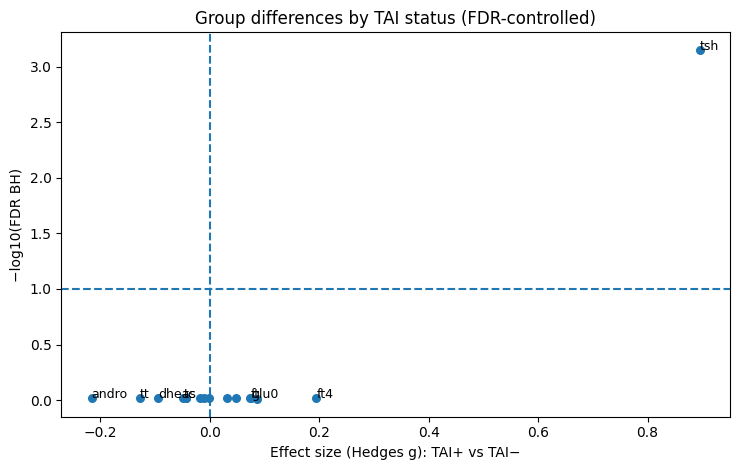

Saved: /content/outputs/figures/F8_volcano_FDR.png


In [ ]:
plot_df = res.dropna(subset=["p_fdr_bh", "hedges_g"]).copy()
plot_df["neglog10_fdr"] = -np.log10(plot_df["p_fdr_bh"].clip(lower=1e-300))

plt.figure(figsize=(7.5, 4.8))
plt.scatter(plot_df["hedges_g"], plot_df["neglog10_fdr"], s=30)

plt.axhline(-np.log10(FDR_TH), linestyle="--")
plt.axvline(0, linestyle="--")

top = plot_df.sort_values(["p_fdr_bh", "abs_g"], ascending=[True, False]).head(8)
for _, r in top.iterrows():
    plt.text(r["hedges_g"], r["neglog10_fdr"], r["variable"], fontsize=9)

plt.xlabel("Effect size (Hedges g): TAI+ vs TAI−")
plt.ylabel("−log10(FDR BH)")
plt.title("Group differences by TAI status (FDR-controlled)")
plt.tight_layout()

out_volcano = figures_dir / "F8_volcano_FDR.png"
plt.savefig(out_volcano, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_volcano)

## Top effects plot

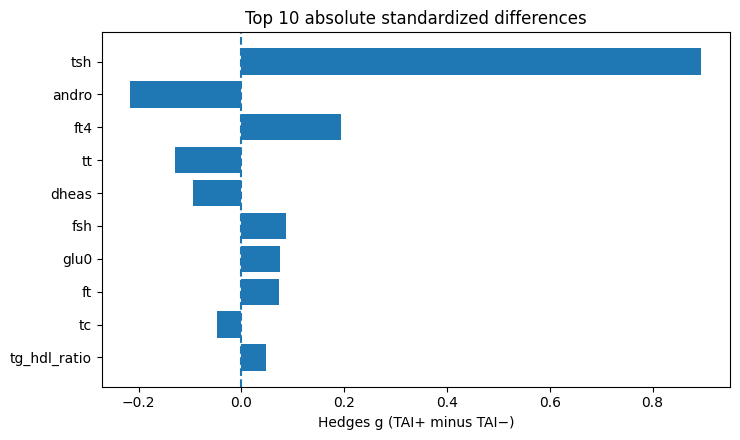

Saved: /content/outputs/figures/F9_top_effects.png


,variable,hedges_g,rank_biserial_corr,p_value,p_fdr_bh,n_TAI_pos_measured,n_TAI_neg_measured,pct_missing_overall
0,tsh,0.895242,0.268397,0.000044,0.000704,84,970,0.09
1,andro,-0.216031,-0.089947,0.272173,0.963592,54,637,34.50
2,ft4,0.194554,0.061416,0.349884,0.963592,84,969,0.19
3,tt,-0.128343,-0.043692,0.506132,0.963592,84,970,0.09
4,dheas,-0.093971,-0.019158,0.770722,0.963592,84,970,0.09
5,fsh,0.086299,-0.001510,0.981817,0.981817,84,970,0.09
6,glu0,0.075348,0.013571,0.841082,0.963592,79,957,1.80
7,ft,0.074097,0.104681,0.127703,0.963592,77,860,11.18
8,tc,-0.048449,-0.046685,0.477421,0.963592,84,969,0.19
9,tg_hdl_ratio,0.047625,-0.012630,0.847705,0.963592,84,969,0.19


In [ ]:
topk = 10
top_eff = res.dropna(subset=["hedges_g"]).copy()
top_eff = top_eff.sort_values("abs_g", ascending=False).head(topk).reset_index(drop=True)

plt.figure(figsize=(7.5, 4.5))
y = np.arange(len(top_eff))[::-1]

plt.barh(y, top_eff["hedges_g"].to_numpy())
plt.yticks(y, top_eff["variable"].to_numpy())
plt.axvline(0, linestyle="--")

plt.xlabel("Hedges g (TAI+ minus TAI−)")
plt.title(f"Top {topk} absolute standardized differences")
plt.tight_layout()

out_top = figures_dir / "F9_top_effects.png"
plt.savefig(out_top, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_top)
top_eff[[
    "variable", "hedges_g", "rank_biserial_corr", "p_value", "p_fdr_bh",
    "n_TAI_pos_measured", "n_TAI_neg_measured", "pct_missing_overall"
]]

## Summary JSON

In [ ]:
summary = {
    "source_used": source_used,
    "analysis_type": "group_comparisons_with_fdr",
    "exposure": EXPOSURE,
    "group_sizes": {
        "n_total_defined_tai": int(len(df_g)),
        "n_tai_pos": int(n_tai_pos_total),
        "n_tai_neg": int(n_tai_neg_total),
    },
    "candidate_markers": CANDIDATE_MARKERS,
    "excluded_from_testing": sorted(list(EXCLUDE_FROM_TESTS)),
    "max_missing_pct_threshold": float(MAX_MISSING_PCT),
    "markers_tested": markers_kept,
    "markers_dropped_for_missingness": markers_dropped,
    "n_markers_tested": int(len(markers_kept)),
    "fdr_threshold": float(FDR_TH),
    "n_fdr_significant": int(res["fdr_significant_0_10"].fillna(False).sum()),
    "top_hits_by_fdr": res.head(10)[
        ["variable", "p_value", "p_fdr_bh", "hedges_g", "rank_biserial_corr"]
    ].to_dict(orient="records"),
}

summary_path = reports_dir / "s7_group_comparisons_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved:", summary_path)
summary

Saved: /content/reports/s7_group_comparisons_summary.json


{'source_used': '/content/pcos_analysis.parquet',
 'analysis_type': 'group_comparisons_with_fdr',
 'exposure': 'tai_A',
 'group_sizes': {'n_total_defined_tai': 1055,
  'n_tai_pos': 84,
  'n_tai_neg': 971},
 'candidate_markers': ['anti_tpo',
  'tsh',
  'ft4',
  'anti_tg',
  'tg',
  'hdl',
  'tc',
  'ldl',
  'non_hdl',
  'tg_hdl_ratio',
  'glu0',
  'glu120',
  'tt',
  'ft',
  'shbg',
  'dheas',
  'andro',
  'amh',
  'lh',
  'fsh'],
 'excluded_from_testing': ['anti_tpo'],
 'max_missing_pct_threshold': 80.0,
 'markers_tested': ['tsh',
  'ft4',
  'tg',
  'hdl',
  'tc',
  'ldl',
  'non_hdl',
  'tg_hdl_ratio',
  'glu0',
  'glu120',
  'tt',
  'ft',
  'dheas',
  'andro',
  'lh',
  'fsh'],
 'markers_dropped_for_missingness': ['anti_tg', 'shbg', 'amh'],
 'n_markers_tested': 16,
 'fdr_threshold': 0.1,
 'n_fdr_significant': 1,
 'top_hits_by_fdr': [{'variable': 'tsh',
   'p_value': 4.402194669556414e-05,
   'p_fdr_bh': 0.0007043511471290263,
   'hedges_g': 0.8952420990707524,
   'rank_biserial_corr'

## Checlist

# Interpretation notes
- This analysis is exploratory and descriptive, intended to screen cross-sectional differences in biochemical markers between TAI+ and TAI− groups.
- Primary group comparisons are performed using Mann–Whitney U tests.
- Multiple testing is controlled using Benjamini–Hochberg FDR.
- anti_tpo is excluded from hypothesis testing because it is definitional for TAI_A.
- Variables with >80% missingness are excluded from testing to reduce unstable inference.
- Hedges' g is reported as a standardized descriptive effect size across markers.
- Rank-biserial correlation is additionally reported as an effect size aligned with MWU.
- Results from S7 should be interpreted as complementary to the regression-based analyses from S5 and S6, not as substitutes for adjusted models.

This analysis represents an exploratory, unadjusted screening analysis intended to identify potential differences in biochemical markers between participants with and without thyroid autoimmunity (TAI, definition A). The purpose of this step is descriptive rather than inferential and it should be interpreted as complementary to the regression-based analyses presented in S05 (primary models) and S06 (secondary models).

Group comparisons were performed using Mann–Whitney U tests due to the non-normal distribution and presence of outliers typical for endocrine and metabolic biomarkers. To account for multiple comparisons across biomarkers, Benjamini–Hochberg false discovery rate (FDR) correction was applied.

Markers with extreme missingness (>80%) were excluded to avoid unstable statistical inference. Additionally, anti-TPO antibodies were excluded from testing because they define the exposure variable (TAI status).

Effect sizes are summarized using Hedges’ g, which provides a standardized measure of the difference between groups, allowing comparisons across biomarkers with different units. Rank-biserial correlation derived from the Mann–Whitney statistic is additionally reported as an effect size aligned with the nonparametric test.

After FDR correction, TSH was the only marker showing a statistically significant difference between TAI+ and TAI− groups, with higher values observed among participants with thyroid autoimmunity. For the remaining biomarkers, no strong evidence of group differences remained after multiple testing correction.

Importantly, these results should be interpreted cautiously. The S07 analysis is not adjusted for potential confounders, and therefore it is not intended to provide causal or etiological inference. The primary interpretation of the study relies on the adjusted regression models presented in S05 and S06, while S07 serves as an exploratory overview of cross-sectional biomarker distributions across TAI groups.